# TorchGWAS Quickstart — MDP Maize EarHT

This notebook mirrors `examples/python/01_single_trait_lmm.py`: fit a Gaussian
single-trait LMM on 276 MDP maize taxa × 3093 SNPs against the `EarHT` and
`dpoll` phenotypes, then render a Manhattan and a QQ plot inline.

**Runtime:** < 15 s on CPU.

**What it demonstrates**

1. Loading numeric genotypes + kinship (GEMMA `.cXX` format) into torch.
2. `SingleTraitLMM.fit_null` → `score_chunk` → BH correction.
3. Manhattan + QQ rendering via `torchgwas.viz`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from torchgwas.config import STAT_DTYPE, NumericalConfig
from torchgwas.models import SingleTraitLMM, VariantMeta
from torchgwas.stats import benjamini_hochberg
from torchgwas.viz import manhattan_plot, qq_plot

REPO_ROOT = Path.cwd().parents[1]
MDP_DATA = REPO_ROOT / "benchmark" / "data"
GEMMA_OUT = REPO_ROOT / "gemma_demo" / "output"

## 1. Load the MDP fixture

We take taxa with complete data on both `EarHT` and `dpoll` (276 samples) so the
sample count matches the GEMMA kinship matrix produced in the same benchmark run.

In [2]:
pheno = pd.read_csv(MDP_DATA / "mdp_traits.txt", sep="\t")
geno = pd.read_csv(MDP_DATA / "mdp_numeric.txt", sep="\t")
snpmap = pd.read_csv(MDP_DATA / "mdp_SNP_information.txt", sep="\t")

pheno["Taxa"] = pheno["Taxa"].astype(str)
geno["taxa"] = geno["taxa"].astype(str)
pheno = pheno[["Taxa", "EarHT", "dpoll"]].dropna(subset=["EarHT", "dpoll"])
common = sorted(set(pheno["Taxa"]) & set(geno["taxa"]))
pheno = pheno[pheno["Taxa"].isin(common)].set_index("Taxa").loc[common]
geno = geno[geno["taxa"].isin(common)].set_index("taxa").loc[common]
snp_names = list(geno.columns)
n, m = geno.shape
print(f"MDP maize: n={n} taxa, m={m} SNPs")

MDP maize: n=276 taxa, m=3093 SNPs


In [3]:
G = torch.tensor(geno.values, dtype=STAT_DTYPE)
for j in range(m):
    col = G[:, j]
    mask = torch.isnan(col)
    if mask.any():
        G[mask, j] = col[~mask].mean()

Y = torch.tensor(pheno["EarHT"].values, dtype=STAT_DTYPE).unsqueeze(1)
X0 = torch.ones(n, 1, dtype=STAT_DTYPE)
K = torch.tensor(
    pd.read_csv(GEMMA_OUT / "mdp_kinship.cXX.txt", sep="\t", header=None).values,
    dtype=STAT_DTYPE,
)

snp_to_cp = {
    str(r["SNP"]): (str(int(r["Chromosome"])), int(r["Position"]))
    for _, r in snpmap.iterrows()
}
chrs = [snp_to_cp.get(s, ("0", 0))[0] for s in snp_names]
pos = [snp_to_cp.get(s, ("0", 0))[1] for s in snp_names]
vmeta = VariantMeta(snp=snp_names, chr=chrs, pos=pos, a1=["A"] * m, a2=["G"] * m)
print(f"Tensors ready: G={tuple(G.shape)}, Y={tuple(Y.shape)}, K={tuple(K.shape)}")

Tensors ready: G=(276, 3093), Y=(276, 1), K=(276, 276)


## 2. Fit the null LMM and scan

We use EMMA-style REML via `NumericalConfig(reml_method="emma")`, which matches
GEMMA at the 4th decimal on this fixture (see `scripts/gemma_agreement_report.py`).

In [4]:
model = SingleTraitLMM(config=NumericalConfig(reml_method="emma"))
nf = model.fit_null(Y, X0, K=K)
print(f"REML vg={float(nf.sig2_g):.4f}  ve={float(nf.sig2_e):.4f}  "
      f"logL={float(nf.log_likelihood):.2f}")

result = model.score_chunk(G, nf, vmeta, test="wald")
p_t = result.p.cpu()
p = p_t.numpy()
beta = result.beta.cpu().numpy()
se = result.se.cpu().numpy()

valid = torch.isfinite(p_t)
bh_valid = benjamini_hochberg(p_t[valid])
bh_p = torch.full_like(p_t, float("nan"))
bh_p[valid] = bh_valid
bh_p = bh_p.numpy()

chr_numeric = np.array(
    [int(c) if str(c).isdigit() else 0 for c in chrs], dtype=int
)
df = pd.DataFrame({
    "snp": snp_names, "chr": chr_numeric, "pos": pos,
    "beta": beta, "se": se, "pval": p, "fdr": bh_p,
})
df.nsmallest(10, "pval")

REML vg=455.6483  ve=104.4323  logL=-1181.13


,snp,chr,pos,beta,se,pval,fdr
452,PZA03188.4,1,280719882,-6.344815,1.575248,0.000073,0.225653
2331,PZA03397.1,7,143547413,-19.460635,5.165842,0.000202,0.312592
243,an1.5,1,175504926,4.877763,1.464948,0.000989,0.908181
2630,PZB00811.1,8,160536300,-8.483957,2.586991,0.001174,0.908181
1110,PZB01892.1,3,161573186,-8.931271,2.840676,0.001849,1.000000
2052,PZB01881.10,6,93263605,8.975773,2.934922,0.002446,1.000000
2695,PZA02916.5,9,15582100,4.297161,1.453972,0.003394,1.000000
1441,PZA03152.2,4,147044761,-9.969779,3.409811,0.003746,1.000000
2932,PZA02945.10,10,33619582,3.924820,1.347116,0.003869,1.000000
1087,PZB00274.4,3,150837246,5.365608,1.849190,0.004014,1.000000


## 3. Manhattan + QQ plots (inline)

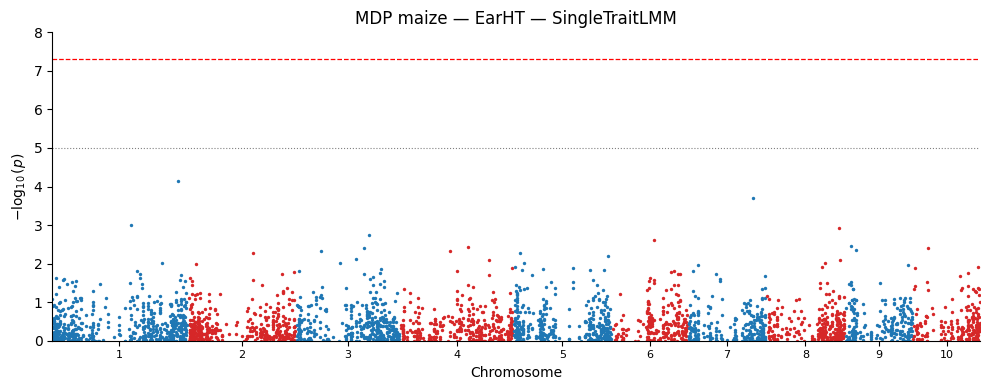

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
manhattan_plot(
    chrom=chr_numeric, pos=np.array(pos, dtype=int), p=p,
    significance_threshold=5e-8, suggestive_threshold=1e-5,
    title="MDP maize — EarHT — SingleTraitLMM",
    ax=ax,
)
plt.tight_layout()
plt.show()

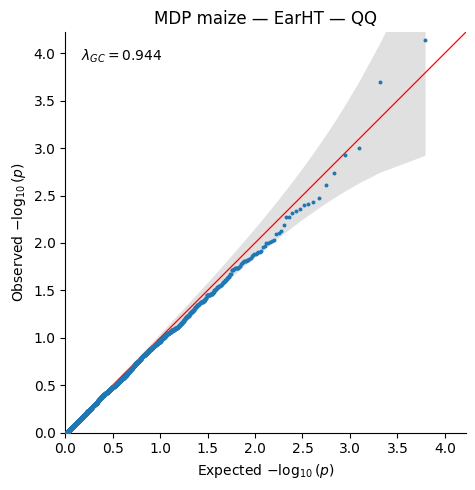

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
qq_plot(p=p, title="MDP maize — EarHT — QQ", ax=ax)
plt.tight_layout()
plt.show()

## Next steps

- `examples/python/02_multi_trait_lmm.py` — bivariate LMM with a shared Vg.
- `examples/python/03_met_scan.py` — multi-environment reaction-norm GWAS.
- `examples/python/05_pgs_construction.py` — build C+T and LDpred2 weights.
- `examples/python/06_fine_mapping.py` — SuSiE credible sets.

See `docs/tutorials/` (rendered at the hosted docs site) for step-by-step
walkthroughs of every module.